In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader, random_split

In [2]:
Zmumu = pd.read_parquet("/data/delphes_Zmumu.parquet")
features_unnormalized = torch.tensor(Zmumu.values, dtype=torch.float32)
features_unnormalized.shape

torch.Size([50000, 25])

In [3]:
dataset = TensorDataset(features_unnormalized)

subset_train, subset_valid, subset_test = random_split(dataset, [0.8, 0.1, 0.1])
len(subset_train), len(subset_valid), len(subset_test)

(40000, 5000, 5000)

In [4]:
class ScaleInputs(nn.Module):
    def __init__(self, subset_train):
        super().__init__()

        loader = DataLoader(subset_train, batch_size=len(subset_train))
        features_tensor, = next(iter(loader))

        self.register_buffer("means", features_tensor.mean(dim=0))
        self.register_buffer("stds", features_tensor.std(dim=0) + 1e-8)

    def forward(self, x):
        return (x - self.means) / self.stds

In [5]:
scaled_inputs = ScaleInputs(subset_train)
scaled_inputs.means.shape, scaled_inputs.stds.shape

(torch.Size([25]), torch.Size([25]))

In [6]:
class Autoencoder(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Linear(12, 8),
            nn.ReLU(),
            nn.Linear(8, 3),
        )

        self.decoder = nn.Sequential(
            nn.Linear(3, 8),
            nn.ReLU(),
            nn.Linear(8, 12),
            nn.ReLU(),
            nn.Linear(12, 16),
            nn.ReLU(),
            nn.Linear(16, n_features),
        )

    def forward(self, features):
        latent = self.encoder(features)
        return self.decoder(latent)

In [7]:
NUM_EPOCHS = 20
BATCH_SIZE = 256

torch.manual_seed(12345)

model = Autoencoder(features_unnormalized.shape[1])
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_loader = DataLoader(subset_train, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(subset_valid, batch_size=BATCH_SIZE, shuffle=False)

train_loss_vs_epoch = []
valid_loss_vs_epoch = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_train_loss = 0.0
    for batch in train_loader:
        (features,) = batch

        optimizer.zero_grad()
        scaled_features = scaled_inputs(features)
        prediction = model(scaled_features)
        loss = loss_function(prediction, scaled_features)
        total_train_loss += loss.item() * features.size(0)

        loss.backward()
        optimizer.step()

    model.eval()
    total_valid_loss = 0.0
    with torch.no_grad():
        for batch in valid_loader:
            (features,) = batch
            scaled_features = scaled_inputs(features)
            prediction = model(scaled_features)
            loss = loss_function(prediction, scaled_features)
            total_valid_loss += loss.item() * features.size(0)

    epoch_train_loss = total_train_loss / len(subset_train)
    epoch_valid_loss = total_valid_loss / len(subset_valid)
    train_loss_vs_epoch.append(epoch_train_loss)
    valid_loss_vs_epoch.append(epoch_valid_loss)

    print(f"epoch={epoch + 1:02d} train_loss={epoch_train_loss:.6f} valid_loss={epoch_valid_loss:.6f}")

epoch=01 train_loss=0.871355 valid_loss=0.717863
epoch=02 train_loss=0.740140 valid_loss=0.565824
epoch=03 train_loss=0.669888 valid_loss=0.527717
epoch=04 train_loss=0.635840 valid_loss=0.497741
epoch=05 train_loss=0.608807 valid_loss=0.474939
epoch=06 train_loss=0.590300 valid_loss=0.456332
epoch=07 train_loss=0.568147 valid_loss=0.436840
epoch=08 train_loss=0.547323 valid_loss=0.420936
epoch=09 train_loss=0.531816 valid_loss=0.410611
epoch=10 train_loss=0.519286 valid_loss=0.404104
epoch=11 train_loss=0.509101 valid_loss=0.399180
epoch=12 train_loss=0.495624 valid_loss=0.392776
epoch=13 train_loss=0.483185 valid_loss=0.395356
epoch=14 train_loss=0.464382 valid_loss=0.392729
epoch=15 train_loss=0.435577 valid_loss=0.385498
epoch=16 train_loss=0.436949 valid_loss=0.408086
epoch=17 train_loss=0.423838 valid_loss=0.375111
epoch=18 train_loss=0.400459 valid_loss=0.372419
epoch=19 train_loss=0.373897 valid_loss=0.372736
epoch=20 train_loss=0.370836 valid_loss=0.372394


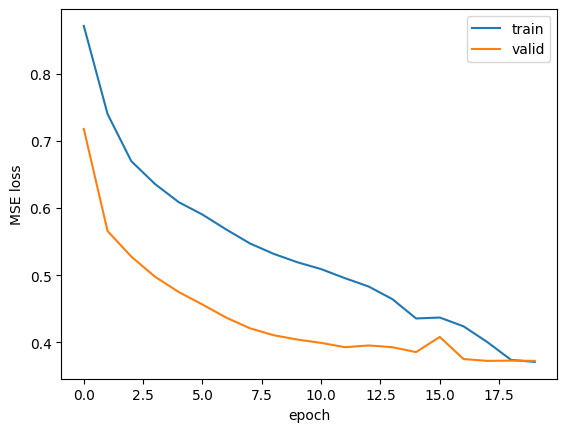

In [8]:
plt.plot(train_loss_vs_epoch, label="train")
plt.plot(valid_loss_vs_epoch, label="valid")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

In [9]:
def get_reco_error_from_loader(model, loader, scaler, device="cpu"):
    model.eval()
    losses = []

    with torch.no_grad():
        for batch in loader:
            x, = batch
            x = x.to(device)

            x_scaled = scaler(x)
            reco = model(x_scaled)
            loss = ((reco - x_scaled) ** 2).mean(dim=1)

            losses.append(loss.cpu())

    return torch.cat(losses).numpy()

In [10]:
ZH = pd.read_parquet("/data/delphes_ZH.parquet")

if list(ZH.columns) != list(Zmumu.columns):
    raise ValueError("ZH and Zmumu parquet files must have the same columns in the same order.")

signal_features = torch.tensor(ZH.values, dtype=torch.float32)
signal_dataset = TensorDataset(signal_features)
signal_loader = DataLoader(signal_dataset, batch_size=BATCH_SIZE, shuffle=False)

signal_features.shape

torch.Size([50000, 25])

In [11]:
err_train = get_reco_error_from_loader(model, train_loader, scaled_inputs)
err_test  = get_reco_error_from_loader(model, valid_loader, scaled_inputs)
err_sig   = get_reco_error_from_loader(model, signal_loader, scaled_inputs)

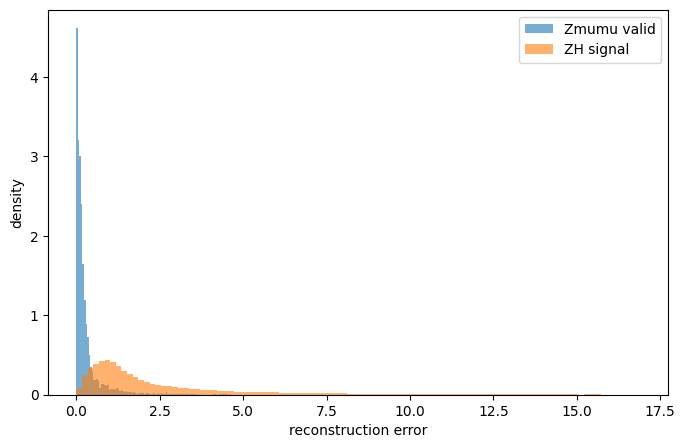

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(err_test, bins=100, range=(0, np.quantile(err_test, 0.99)), alpha=0.6, density=True, label="Zmumu valid")
plt.hist(err_sig, bins=100, range=(0, np.quantile(err_sig, 0.99)), alpha=0.6, density=True, label="ZH signal")
plt.xlabel("reconstruction error")
plt.ylabel("density")
plt.legend()
plt.show()


In [13]:
pd.DataFrame({
    "sample": ["Zmumu valid", "ZH signal"],
    "mean_reco_error": [err_test.mean(), err_sig.mean()],
    "median_reco_error": [np.median(err_test), np.median(err_sig)],
    "p95_reco_error": [np.quantile(err_test, 0.95), np.quantile(err_sig, 0.95)],
})

,sample,mean_reco_error,median_reco_error,p95_reco_error
0,Zmumu valid,0.372394,0.141102,1.369137
1,ZH signal,4.542386,1.505620,9.541677


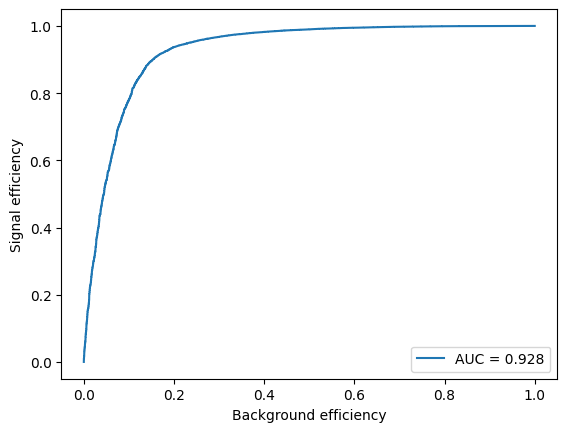

In [15]:
from sklearn.metrics import roc_curve, auc

y_true = np.concatenate([
    np.zeros_like(err_test),
    np.ones_like(err_sig)
])

scores = np.concatenate([err_test, err_sig])

fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("Background efficiency")
plt.ylabel("Signal efficiency")
plt.legend()
plt.show()